In [1]:
import xml.etree.ElementTree as ET
import numpy as np

# 1. Load the repaired XML file
tree = ET.parse('Mn4N_4pct_N2_[PIX]_GIXRD_30-90_0p1_0p1dps_15reps_3hrs.xrdml')
root = tree.getroot()

# The namespace PANalytical uses
ns = {'xrd': 'http://www.xrdml.com/XRDMeasurement/2.1'}

# 2. Extract the 2-Theta X values (Start and End)
pos = root.find('.//xrd:positions[@axis="2Theta"]', ns)
start_x = float(pos.find('xrd:startPosition', ns).text)
end_x = float(pos.find('xrd:endPosition', ns).text)

# 3. Extract the counts (Y values)
# Note: Your file is a "Repeated scan" with multiple <scan> blocks. 
# This gathers all scans and sums their intensities.
y_data = []
for counts in root.findall('.//xrd:counts', ns):
    # Convert space-separated string of numbers into a numpy array
    scan_y = np.fromstring(counts.text, sep=' ')
    y_data.append(scan_y)

# Sum all the repeated scans together
y = np.sum(y_data, axis=0)

# 4. Generate the X array based on the start/end positions and the number of Y points
x = np.linspace(start_x, end_x, len(y))

print("Data loaded successfully!")
print(f"X (2-Theta) array size: {len(x)}")
print(f"Y (Intensity) array size: {len(y)}")

Data loaded successfully!
X (2-Theta) array size: 610
Y (Intensity) array size: 610


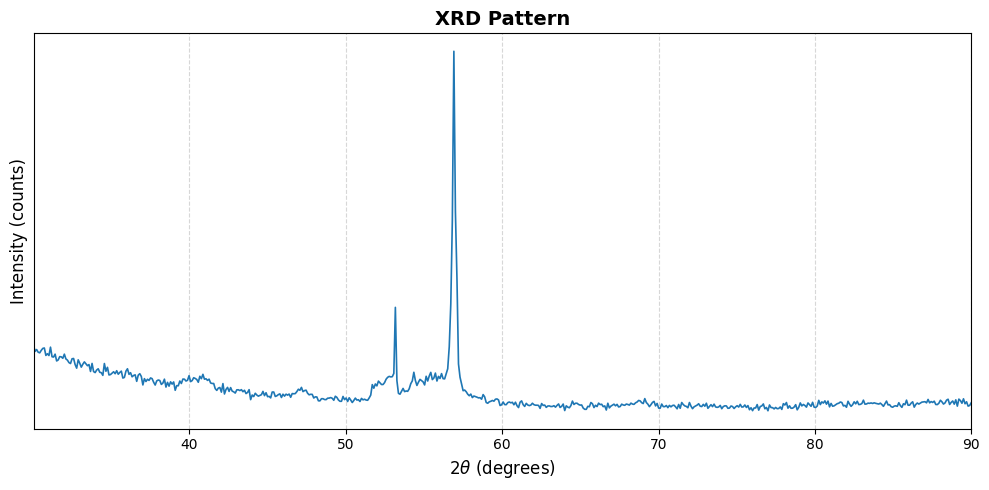

In [2]:
import matplotlib.pyplot as plt
import numpy as np # Assumed imported based on your np.max/np.min usage

# Assuming x and y are already defined here
# x = ...
# y = ...

# --- Shift the values by 10 degrees ---
#x_shifted = x - 10.0

plt.figure(figsize=(10, 5)) # Sets the width and height of the figure
# Plot using the new shifted x values
plt.plot(x, y, color='#1f77b4', linewidth=1.2) # A clean blue line

# Format it to look like a standard XRD publication plot
plt.title('XRD Pattern', fontsize=14, fontweight='bold')
plt.xlabel('2$\\theta$ (degrees)', fontsize=12) 
plt.ylabel('Intensity (counts)', fontsize=12)

#print(x_shifted[273])

# Tidy up the axes using the new shifted x limits
plt.xlim(np.min(x), np.max(x))
plt.grid(True, linestyle='--', alpha=0.5) # Adds a light grid for readability
plt.gca().get_yaxis().set_ticks([]) # Hides the Y numbers

# Show the plot
plt.tight_layout()
plt.show()

np.savetxt(r'C:\Users\Owner\OneDrive\Desktop\shifted_XRD_data.txt', y, fmt='%.5f', delimiter='\t')

In [3]:
x[1]-x[0]

np.float64(0.09847712026272504)

In [4]:
np.min(x)

np.float64(30.02743856)

In [4]:
np.max(x)

np.float64(90.0000048)

In [5]:
x[273]

np.float64(56.91169239172414)

In [13]:
for i in range(len(y)):
    if y[i] > 1000:
        print(i)

235
271
272
273
274
275


In [15]:
x[235]

np.float64(53.16956182174056)

In [ ]:
import numpy as np

# Assuming x_shifted and y are already calculated
# x_shifted = x + 10

# Combine the arrays into two columns
data_to_save = np.column_stack((x_shifted, y))

# Save directly to a .xy file
# Note: The header has been removed for better compatibility with XRD software
# delimiter=' ' uses a standard space to separate the columns
np.savetxt('shifted_XRD_data.xy', data_to_save, fmt='%.5f', delimiter=' ')

print("Data successfully saved to 'shifted_XRD_data.xy'")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your file path
filename = r"C:\Users\Owner\OneDrive\Desktop\ViT_for_XRD\Databases\Real_data\1.xy" # Paste here  # Replace with your actual file name

# 2. Load the data
# np.genfromtxt handles plain text files easily. 
# If your .xy file has a few lines of text at the top (like column names or instrument parameters), 
# change 'skip_header=0' to the number of text lines to skip (e.g., skip_header=2).
#data = np.genfromtxt(filename, skip_header=0)
data = np.genfromtxt(filename, delimiter=',')
data = np.array(data)

# 3. Extract columns into X and Y arrays
x_tilde = data[:,0]  # First column: 2-Theta
y_tilde = data[:,1]  # Second column: Intensity
#print(x)
# 4. Create and customize the plot
plt.figure(figsize=(10, 5)) # Sets the width and height of the figure
plt.plot(x_tilde, y_tilde, color='#1f77b4', linewidth=1.2) # A clean blue line

# 5. Format it to look like a standard XRD publication plot
plt.title('XRD Pattern', fontsize=14, fontweight='bold')
plt.xlabel('2$\\theta$ (degrees)', fontsize=12) # Note: Uses simple string formatting for the Greek letter
plt.ylabel('Intensity (a.u.)', fontsize=12)

print(x)
# Optional: Tidy up the axes
#plt.xlim(0, np.max(x)) # Makes the x-axis tightly hug your data range
plt.xlim(np.min(x), np.max(x))
plt.grid(True, linestyle='--', alpha=0.5) # Adds a light grid for readability
plt.gca().get_yaxis().set_ticks([]) # Often, absolute intensity numbers don't matter in XRD, so this hides the Y numbers

# 6. Show the plot
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import median_filter


file_path = r"C:\Users\Owner\OneDrive\Desktop\ViT_for_XRD\Databases\Classification_2\Mn4N_ferri1.txt"

# np.loadtxt automatically reads the numbers, and skiprows=1 skips your header line
raw_intensity = np.loadtxt(file_path, skiprows=1)

# Simulating a 2-theta array from 10 to 80 degrees
two_theta = np.linspace(20.32743856, 80.3000048, 611)

# Simulating a background (polynomial curve)
background_true = 100 + 5 * two_theta - 0.05 * two_theta**2 

# Simulating a few peaks (Gaussians)
peak1 = 800 * np.exp(-((two_theta - 28.5) / 0.2)**2)
peak2 = 400 * np.exp(-((two_theta - 47.3) / 0.3)**2)
peak3 = 600 * np.exp(-((two_theta - 56.1) / 0.25)**2)

# Combined raw continuous pattern with some noise
#raw_intensity = background_true + peak1 + peak2 + peak3 + np.random.normal(0, 10, len(two_theta))

# ==========================================
# 1. Background Subtraction
# ==========================================
# Use a median filter with a large window to estimate the background.
# The window size (e.g., 101 points) should be wider than your widest peak.
estimated_background = median_filter(raw_intensity, size=101)

# Subtract background and clip negative values to 0
intensity_bg_removed = raw_intensity - estimated_background
intensity_bg_removed = np.clip(intensity_bg_removed, 0, None)

# ==========================================
# 2. Normalization
# ==========================================
# Normalize so the maximum peak intensity is 100
max_val = np.max(intensity_bg_removed)
intensity_normalized = (intensity_bg_removed / max_val) * 100

# ==========================================
# 3. Peak Finding using find_peaks_cwt
# ==========================================
# find_peaks_cwt requires an array of expected peak widths (in array indices, not degrees).
# If your peaks are roughly 10 to 30 data points wide, provide that range.
expected_widths = np.arange(10, 30)

# Identify the indices where peaks occur
peak_indices = signal.find_peaks_cwt(intensity_normalized, expected_widths)

# Extract the 2-theta and intensity values for the stick pattern
stick_2theta = two_theta[peak_indices]
stick_intensities = intensity_normalized[peak_indices]

# ==========================================
# 4. Convert 2-Theta to d-spacing
# ==========================================
wavelength = 1.5406 # Cu K-alpha in Angstroms

# Convert 2-theta (degrees) -> theta (degrees) -> theta (radians)
theta_radians = np.radians(stick_2theta / 2)

# Apply Bragg's Law
d_spacings = wavelength / (2 * np.sin(theta_radians))

# ==========================================
# 5. Output and Visualization
# ==========================================
print("Extracted Stick Pattern:")
print("2-Theta (°)\t d-spacing (Å)\t Intensity (%)")
print("-" * 55)
for t2, d, i in zip(stick_2theta, d_spacings, stick_intensities):
    print(f"{t2:8.3f}\t {d:10.4f}\t {i:10.2f}")

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot the raw data and estimated background
plt.plot(two_theta, raw_intensity, label="Raw Data", color='lightgray')
plt.plot(two_theta, estimated_background, label="Estimated Background", color='red', linestyle='--')

# Plot the background-subtracted, normalized continuous pattern
# Scaled back up to fit on the same visual axis for demonstration, 
# or plotted on a secondary axis (here we just plot the normalized version directly)
plt.plot(two_theta, intensity_normalized, label="Processed & Normalized", color='blue')

# Plot the extracted stick pattern
plt.vlines(x=stick_2theta, ymin=0, ymax=stick_intensities, color='orange', label="Extracted Sticks", linewidth=2)

plt.xlabel('2-Theta (degrees)')
plt.ylabel('Intensity')
plt.title('XRD Pattern Reduction: Continuous to Stick')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import xml.etree.ElementTree as ET
import numpy as np

# 1. Put the exact name of your saved file here
filename = 'Mn4N_4pct_N2_[PIX]_GIXRD_30-90_0p1_0p1dps_15reps_3hrs.xrdml'

# Load and parse the XML data
tree = ET.parse(filename)
root = tree.getroot()

# The namespace required to read PANalytical xrdml files
ns = {'xrd': 'http://www.xrdml.com/XRDMeasurement/2.1'}

# Extract all repeated scans
scans = root.findall('.//xrd:scan', ns)

# Loop through all scans and collect the intensity counts
all_counts = []
for scan in scans:
    counts_text = scan.find('.//xrd:counts', ns).text
    counts = np.array([int(c) for c in counts_text.split()])
    all_counts.append(counts)

# Sum the counts across all repeated scans to boost the thin film signal
summed_counts = np.sum(all_counts, axis=0)

# Extract the starting and ending 2Theta angles
positions = scans[0].find('.//xrd:positions[@axis="2Theta"]', ns)
start_2theta = float(positions.find('xrd:startPosition', ns).text)
end_2theta = float(positions.find('xrd:endPosition', ns).text)

# Generate the 2Theta angle axis based on the number of data points
num_points = len(summed_counts)
two_theta = np.linspace(start_2theta, end_2theta, num_points)

# Export to a 2-column .xy file suitable for QualX2.0
output_filename = 'QualX_ready_data.xy'
with open(output_filename, 'w') as f:
    for t, c in zip(two_theta, summed_counts):
        # Format: 2Theta (rounded to 5 decimals) [tab] Intensity
        f.write(f"{t:.5f}\t{int(c)}\n")
        
print(f"Conversion complete! File successfully saved as {output_filename}")